# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 24 - 2do bimestre 2026


Este tercer y último TP se debe entregar hasta las **23:59hs del viernes 19 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía que consideren que les haga falta. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/56R6couXZBPDZzfs5)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP3-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

Les recomiendo usar el siguiente código para poder obtener las imágenes fácilmente desde ese link. Pero son libres de descargar las imágenes como mejor les parezca.

In [3]:
import gdown
import zipfile
import os

url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
output = "archivo.zip"

gdown.download(url, output, quiet=False)

destino = "datos_zip"
os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

DATASET_ROOT_TRAIN = '/content/datos_zip/dataset_emociones/train'
DATASET_ROOT_VAL   = '/content/datos_zip/dataset_emociones/validation'


Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=84cf9c73-36d3-4622-a975-27824edfbdcb
To: c:\Users\IanEz\OneDrive\Documentos\GitHub\Aprendizaje-Profundo\Practica\TP_N3\archivo.zip
100%|██████████| 40.0M/40.0M [00:03<00:00, 10.9MB/s]


## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



<p>Se revisa la documentación provista sobre "torchvision.transforms". De la revisión de la misma, se concluye que será útil el modulo "functional" ya que permiten mayor control sobre las transformaciones a aplicar.</p>
<p><b>Transformaciones:</b><br>Para determinar qué transformaciones necesitamos, primero deberemos explorar nuestro dataset:</p>

In [ ]:
import PIL 
import matplotlib.pyplot as plt
import torch
from torch import nn
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import numpy as np

In [2]:
#Genero un diccionario para mapear los labels
label_dict = {
       '0':        'alegria' ,
       '1':        'disgusto',
       '2':        'enojo',
       '3':        'miedo',
       '4':        'seriedad',
       '5':        'sorpresa',
       '6':        'tristeza'
}
#Genero una función para poder obtener un label categórico en base al diccionario definido
def getLabel(label):
    return (dict[str(label.item())])

In [ ]:
#Defino ruta donde se encuentran almacenadas las imagenes
train_data_path = r'.\datos_zip\dataset_emociones\train'
test_data_path = r'.\datos_zip\dataset_emociones\validation'

In [ ]:
import pandas as pd
from pathlib import Path
import imagesize

# 1. Get the Image Resolutions using recursive globbing
# rglob("*.jpg") will automatically dig into /happiness/, /fear/, etc.
path = Path(train_data_path)
img_meta = {}

for img_path in path.rglob("*.jpg"):
    # imagesize.get() safely accepts pathlib Path objects directly, 
    # saving us from string concatenation errors!
    img_meta[img_path.name] = imagesize.get(img_path)

# 2. Build a structured list for Pandas
# This prevents the ValueError by ensuring exactly 3 columns are created per row
data_rows = []
for filename, size in img_meta.items():
    data_rows.append({
        "FileName": filename,
        "Width": size[0],
        "Height": size[1]
    })

# 3. Convert directly to DataFrame
img_meta_df = pd.DataFrame(data_rows)

# 4. Compute Aspect Ratio (Protected by an empty check)
if not img_meta_df.empty:
    img_meta_df["Aspect Ratio"] = round(img_meta_df["Width"] / img_meta_df["Height"], 2)
    
    print(f'Total Nr of Images in the dataset: {len(img_meta_df)}')
    print(f'Valores únicos de "Widht" {img_meta_df['Width'].unique()}')
    print(f'Valores únicos de "Height" {img_meta_df['Height'].unique()}')
else:
    print("No se encontraron imagenes en 'trian_data_path'")

Total Nr of Images in the dataset: 12271
Valores únicos de "Widht" [100]
Valores únicos de "Height" [100]


<p>Se comprueba que todas las imágenes poseen el mismo tamaño, con lo cuál, no será necesario aplicar un Resize

In [ ]:

#TODO: Definir transformaciones
transform = transforms.Compose(
    
     [transforms.Grayscale(1),          #nos quedamos con imagenes en escala de grises, ya que en este caso la información no está en el color
      transforms.RandomEqualize(p=1.0), #ecualizamos el histograma de las imagenes para lograr mayor constraste y detalle en las mismas (p=1 => se aplica el 100% de las veces)     
      transforms.ToTensor(),            #convertimos a tensores ya que es el formato requerido para la CNN.  
      transforms.Normalize(0.5,0.5)])   #Normalizamos los datos. De la documentación:  output[channel] = (input[channel] - mean[channel]) / std[channel]. Si queremos que la media 0 u rango -1 a 1, usamos mean=0.5 y std=0.5

#Cargo mi dataset
train_dataset = datasets.ImageFolder(train_data_path,transform=transform)

#Definimos el DataLoader
train_dl = DataLoader(train_dataset,
                                         batch_size=32,
                                         shuffle=True)

In [84]:
#Extraigo un batch de imagenes con sus labels
images, labels = next(iter(train_dl))

#me quedo con la primera imagen, primer canal 
image = images[0][0]
#extraigo el label
label = getLabel(labels[0])

<p>Veamos una de las imágenes obtenidas y su label

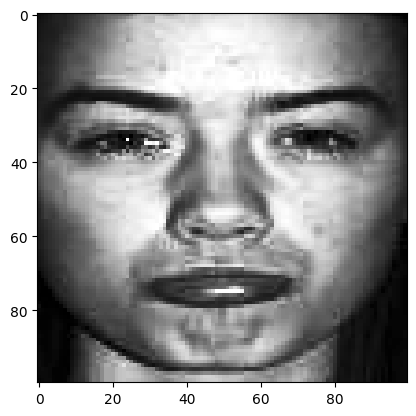

In [85]:
#Imprimo la imagen
plt.imshow(image, cmap='gray')

In [99]:
#imprimimos el label
print(label)

tristeza


<p>Revisemos distribución del label

In [ ]:
#Extraigo en una lista, todos los valores de labels de todos los batches del dataloader
labels = []
train_dl_iter = iter(train_dl)
while True:
    try:
        batch_images, batch_labels = next(train_dl_iter)
        labels.extend(batch_labels.numpy().tolist())
    except:
        break

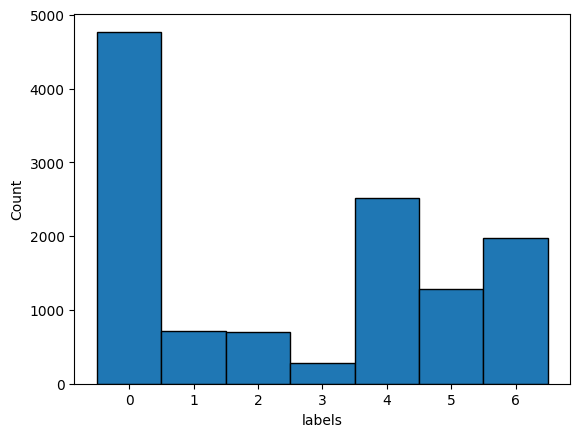

In [116]:
plt.hist(labels,bins=[-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5], edgecolor='black')
plt.xlabel('labels')
plt.ylabel('Count')
plt.show()

<p>Vemos que el target no está equitativamente distrubido, siendo la clase 0 la que más muestras posee; mientras que la clase 3, posee significativamente menos

<p>Podemos aplicar un "Weigthed Random Sampler" para asegurar que en cada batch, el modelo reciba una muestra balanceada de clases (<i>Fuente: <link>https://www.geeksforgeeks.org/deep-learning/handling-class-imbalance-in-pytorch/</link>)</p>.
<p>De todas formas, para evitar un <i>overfitting</i> de las clases minoritarias, aplicaremos tambien <i>Data Augmentation</i> utilizando transformaciones provistas por Pytorch

In [27]:
from torch.utils.data import WeightedRandomSampler

In [ ]:
#Modificamos las transformaciones anteriores, para aplicar data Augmentation
transform = transforms.Compose(
    
     [transforms.Grayscale(1),          #nos quedamos con imagenes en escala de grises, ya que en este caso la información no está en el color
      transforms.RandomRotation(10),    #Aplicamos una rotación randomizada de hasta 10 grados  
      transforms.RandomHorizontalFlip(0.5), #Espejamos en eje horizontal con una probabilidad de 0.5  
      transforms.RandomEqualize(p=1.0), #ecualizamos el histograma de las imagenes para lograr mayor constraste y detalle en las mismas (p=1 => se aplica el 100% de las veces)     
      transforms.ToTensor(),            #convertimos a tensores ya que es el formato requerido para la CNN.  
      transforms.Normalize(0.5,0.5)])   #Normalizamos los datos. De la documentación:  output[channel] = (input[channel] - mean[channel]) / std[channel]. Si queremos que la media 0 u rango -1 a 1, usamos mean=0.5 y std=0.5

#Cargo mi dataset
train_dataset = datasets.ImageFolder(train_data_path,transform=transform)

#obtenemos los pesos de cada clase
class_weights  = []
sample_weights = []
labels = [0,1,2,3,4,5,6]
for label in labels:
    class_weights.append(1/train_dataset.targets.count(label))

#debemos asignar a cada muestra, su "class_weight"
for indx in range(len(train_dataset.targets)):
    #obtengo el label de la muestra correspondiente al índice actual
    label = train_dataset.targets[indx]
    #utilizando la lista "class_weights" guardo el peso correspondiente a la muestra (notar que los pesos se almacenan en orden de label, de 0 a 6)
    sample_weights.append(class_weights[label])

#pasamos a tensor los pesos y definimos el "sampler"
sample_weights = torch.tensor(sample_weights)
sampler = WeightedRandomSampler(weights=sample_weights,num_samples=len(train_dataset.targets))

#Generemos le data_loader
train_dl = DataLoader(train_dataset, batch_size=32, sampler=sampler)

In [43]:
#Extraigo en una lista, todos los valores de labels de todos los batches del dataloader
labels = []
train_dl_iter = iter(train_dl)
while True:
    try:
        batch_images, batch_labels = next(train_dl_iter)
        labels.extend(batch_labels.numpy().tolist())
    except:
        break

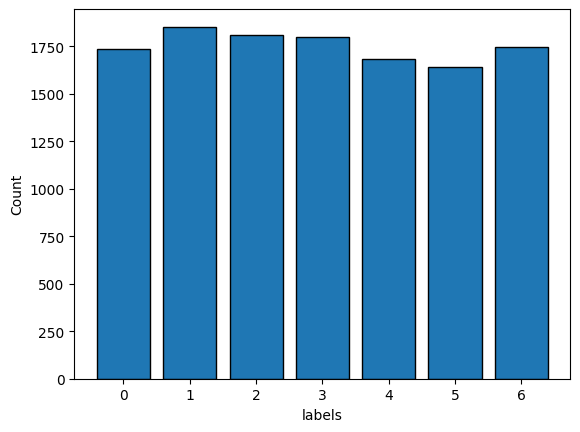

In [46]:
plt.hist(labels,bins=[-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5], edgecolor='black',rwidth=0.8)
plt.xlabel('labels')
plt.ylabel('Count')
plt.show()

<p>Observamos ahora que tenemos un balance mucho mayor entre cada clase por época de entrenamiento

<p>Repetimos para el test de validación

In [50]:
#Modificamos las transformaciones anteriores, para aplicar data Augmentation
test_transform = transforms.Compose(
    
     [transforms.Grayscale(1),          #nos quedamos con imagenes en escala de grises, ya que en este caso la información no está en el color
      transforms.ToTensor(),            #convertimos a tensores ya que es el formato requerido para la CNN.  
      transforms.Normalize(0.5,0.5)])   #Normalizamos los datos. De la documentación:  output[channel] = (input[channel] - mean[channel]) / std[channel]. Si queremos que la media 0 u rango -1 a 1, usamos mean=0.5 y std=0.5


#Cargo mi dataset
test_dataset = datasets.ImageFolder(test_data_path,transform=test_transform)

#Generemos el data_loader
test_dl = DataLoader(test_dataset, batch_size=32,shuffle=False)

## 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

In [48]:
#definimos bloque de convolución
def conv_block(c_in, c_out, k=3, p='same', s=1, pk=2):        
    return torch.nn.Sequential(                               
        torch.nn.Conv2d(c_in, c_out, k, padding=p, stride=s), # convolución
        torch.nn.ReLU(),                                      # activación
        torch.nn.MaxPool2d(pk)                                # pooling
    )

In [54]:
#Debemos definir una clase propia para nuestro modelo que herede de la clase "nn.Module"
#   Sobreescribimos el método forward que es llamado luego "internamente"
class Model(nn.Module):
    #
    #
    #   @fn:           __init__ 
    #   @brief:        declaramos todas las capas y características de nuestro modelo    
    #   @parameters:    
    #                       n_channels:     nro de canales de nuestras imagenes (1 en nuestro caso porque es escala de grises)
    #                       n_outputs:      nro de salidas (7 en nuestro caso; una por cada emoción)
    #                       channels:       Número de canales de cada kernel (o número de subkerles de cada capa)        
    #                       kernel_size:    Tamaño de los kernels
    #                       dropout:        probabilidad de dropout
    #                       padding:        'valid' (kernel no sale de la imagen. Reduce dimension) o 'same' (Kernel puede salir de la imagen. No reduce dimensión)
    #                       stride:         paso que da el kernel sobre la imagen
    #                       pool_kernel:    tamaño del kernel de la capa de pooling
    # 
    #    
    def __init__(self,n_channels, n_outputs, channels, kernel_size, dropout, padding, stride, pool_kernel,fc_input_neurons):
        super().__init__() #debemos llamarlo porque estamos heredando de "nn.Module"
        
        
        #TODO: verifica uso
        self.dropout = nn.Dropout(dropout)
        self.n_channels = n_channels
        self.n_outputs = n_outputs
        self.channels = tuple(channels)
        self.kernel_size = kernel_size
        self.dropout_p = dropout
        self.padding = padding
        self.stride = stride
        self.pool_kernel = pool_kernel
        self.num_conv_blocks = len(self.channels)

        #defino capas de convolución
        self.conv1 = conv_block(c_in=self.n_channels, c_out=self.channels[0], k=self.kernel_size, p=self.padding, s=self.stride, pk=self.pool_kernel)
        self.conv1_out = None
        self.conv2 = conv_block(c_in=self.channels[0], c_out=self.channels[1], k=self.kernel_size, p=self.padding, s=self.stride, pk=self.pool_kernel)
        self.conv2_out = None
        self.conv3 = conv_block(c_in=self.channels[1], c_out=self.channels[2], k=self.kernel_size, p=self.padding, s=self.stride, pk=self.pool_kernel)
        self.conv3_out = None

        #defino la arquitectura del "multi layer perceptron"
        self.fully_connectd = nn.Sequential(
            #Capa de entrada
            #capa fully connected
            nn.Linear(fc_input_neurons, 32),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            #capa de salida
            nn.Linear(32, 7),
            )
        
    #
    #
    #   @fn:            forward
    #   @brief:         definimos cómo se usará el modelo definido en __init__
    #   @parameters:    
    #                    X: set de imagenes
    #                    
    #                    
    #                    
    #                    
    #
    def forward(self,X):
        
        self.conv1_out = self.conv1(X)
        self.conv2_out = self.conv2(self.conv1_out)
        self.conv3_out = self.conv3(self.conv2_out)
        #aplicamos un dropout inicial a nuestros datos (ponemos a 0 ciertos datos, entonces el modelo entrena sin ellos y lo forzamos a aprender otros patrones)
        # Es para prevenir overfitting
        y = self.dropout(self.conv3_out)
        y = y.flatten(start_dim=1)
        #Aplicamos nuestra red "fully connected" a los datos
        out = self.fully_connectd(y)
        #Convertimos la salida en un vector de una sola dimension (como suele ser "y", el ground truth)
        return out.squeeze(1)

In [55]:
import math

#verificamos si está disponible el GPU y si es así, para usarlo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_channels=1            #tenemos un canal en nuestras imágenes
n_outputs=7             #tenemos siete clases para la salida
channels=(16, 16, 16)   #inicio con 16 sub-kernels por capa, se modificará si no se encuentra un buen rendimiento
kernel_size=10          #dado que nuestras imágenes son de 100x100, se elige en principio un Kernel de 10x10, para que "entre" 10 veces en la imagen
dropout=0.3             
padding='same'          #elegimos padding "same" para no disminuir la dimensionalidad, aún sabiendo que en algunas zonas el kernel abarcará celdas vacías
stride=1                #defino que el paso a dar por el kernel sea de un pixel por vez
pool_kernel=2           #defino un kernel para el pooling que divide por la mitad el tamaño de la imagen
conv_blocks = 3

#calculo el número de neuronas de entrada de la red fully connected
final_image_dim = math.floor(100 / (pool_kernel ** conv_blocks))
fc_in_neurons = channels[2] * (final_image_dim ** 2)


#defino learning rate
lr = 0.001
#seteo número de épocas de entrenamiento
epochs = 50

#instancio mi modelo
model = Model(n_channels=n_channels, 
              n_outputs=n_outputs, 
              channels=channels, 
              kernel_size=kernel_size, 
              dropout=dropout, 
              padding=padding, 
              stride=stride, 
              pool_kernel=pool_kernel,
              fc_input_neurons=fc_in_neurons)
#paso a GPU
model = model.to(device)

#Usamos "Binary Cross Entropy Loss" ya que tenemos que clasificar entre exactamente dos clases
#bce_loss = nn.BCELoss()
bce_loss = nn.CrossEntropyLoss() #utilizamos Categorial Cross Entropy ya que tenemos más de una clase


#Usaremos función de optimización tipo Adam
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


In [ ]:
#defino listas para almacenar la evolución del loss
cel_train_his = []
cel_test_his  = []

f1_train_his = []
f1_test_his = []

acc_train_his = []
acc_test_his = []



for epoch in range(epochs+1):
    #seteamos modelo en modo entrenamiento (se habilita, por ejemplo, el dropout)
    model.train()

    batch_cel_train = []
    batch_f1_train = []
    train_preds = []
    train_targets = []

    #desempaquetamos nuestros datos
    for edu,occ,ski,cou,num,y in train_dl:
        #pasamos todo a GPU si está disponible
        edu = edu.to(device);occ = occ.to(device);cou = cou.to(device);ski = ski.to(device);num = num.to(device); y = y.to(device)

        #aplicamos nuestro modelo para obtener la predicción
        pred = model(edu,occ,ski,cou,num)

        #computamos el valor de la función de pérdida
        loss = bce_loss(pred,y)
        batch_cel_train.append((loss.item()))

        #Lógica de métricas
        # Transformo las predicciones devueltas por el modelo a probabilidades (rango 0 a 1)
        probs = torch.sigmoid(pred)
        #Si la probabilidad es > 0.5, es clase 1. Si no, es clase 0.
        classes = (probs > 0.5).int()
        #almaceno las clases predichas en el batch
        train_preds.extend(classes.cpu().numpy()) #extend similar a "append" pero agrega todos los elementos a la lista como elementos de la lista (no como sub-lista, como haría append) https://www.geeksforgeeks.org/python/append-extend-python/
        #almaceno los targets del batch (guardamos en  numpy para utilizar con Sklearn)
        train_targets.extend(y.cpu().numpy())

        #limpiamos los gradientes de batch anterior, para calcular luego en el paso backward los de esta iteración
        optimizer.zero_grad()
        #Realizamos el paso de backpropagation
        loss.backward()
        #Actualizamos los parámetros del modelo utilizando los gradientes calculados en el paso anterior
        optimizer.step()



    #guardo la pérdida BCE obtenida en esta época (como la media de la BCE de cada batch)
    cel_train_his.append(np.mean(batch_cel_train))
    #computyo el accuracy de train para la época
    acc_train_his.append(accuracy_score(train_targets,train_preds))
    #computo el f1 de train para la época
    f1_train_his.append(f1_score(train_targets,train_preds))

    #### Evaluación de modelo ####
    #Pasamos a eval
    model.eval()
    batch_bce_test = []
    batch_f1_test = []
    test_preds = []
    test_targets = []
    #desactivamos el cálculo de gradientes (utilizado en backpropagation). Esto ahorra recursos y tiempo
    with torch.no_grad():
        for edu,occ,ski,cou,num,y in test_dl:
            #pasamos todo a GPU si está disponible
            edu = edu.to(device);occ = occ.to(device);cou = cou.to(device);ski = ski.to(device);num = num.to(device);y = y.to(device)

            #aplicamos nuestro modelo para obtener la predicción
            pred = model(edu,occ,ski,cou,num)

            #computamos el valor de la función de pérdida
            loss = bce_loss(pred,y) 
            batch_bce_test.append(loss.item())

            #Lógica de métricas
            # Transformo las predicciones devueltas por el modelo a probabilidades (rango 0 a 1)
            probs = torch.sigmoid(pred)
            #Si la probabilidad es > 0.5, es clase 1. Si no, es clase 0.
            classes = (probs > 0.5).int()
            #almaceno las clases predichas en el batch
            test_preds.extend(classes.cpu().numpy()) #extend similar a "append" pero agrega todos los elementos a la lista como elementos de la lista (no como sub-lista, como haría append) https://www.geeksforgeeks.org/python/append-extend-python/
            #almaceno los targets del batch (guardamos en  numpy para utilizar con Sklearn)
            test_targets.extend(y.cpu().numpy())


        cel_test_his.append(np.mean(batch_bce_test))
        #computyo el accuracy de test para la época
        acc_test_his.append(accuracy_score(test_targets,test_preds))
        #computo el f1 de test para la época
        f1_test_his.append(f1_score(test_targets,test_preds))      



# Imprimir resumen de la época
    print(f"Epoch {epoch} | Train BCE: {cel_train_his[-1]:.4f} | Test BCE: {cel_test_his[-1]:.4f} | Test Acc: {acc_test_his[-1]:.4f} | Test F1: {f1_test_his[-1]:.4f}")


        



## 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.


 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 12 imágenes personales de cualquier ratio o relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación. Tampoco vale usar imágenes de otro dataset, deben ser imágenes sueltas.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones que durante el entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase esperada
  - La clase ganadora inferida por el modelo

- Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:

  - Similitudes entre emociones.
  - Mezcla de 2 o más emociones en una misma expresión.

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

**IMPORTANTE:** Ajusten los parámetros `scaleFactor`, `minNeighbors` y `minSize` según convenga para que la detección de rostros sea más efectiva y logre detectar rostros en sus 12 imágenes. No se queden necesariamente con los valores por defecto.

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

image_path = ""

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6, minSize=(30,30))

image_with_box = image.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(image_with_box, (x, y), (x + w, y + h), (0, 255, 0), 2)

cropped_face_rgb = None
if len(faces) > 0:
    (x, y, w, h) = faces[0]
    center_x, center_y = x + w // 2, y + h // 2
    side = max(w, h)
    half_side = side // 2

    x1 = max(center_x - half_side, 0)
    y1 = max(center_y - half_side, 0)
    x2 = min(center_x + half_side, image.shape[1])
    y2 = min(center_y + half_side, image.shape[0])

    cropped_face = image[y1:y2, x1:x2]
    cropped_face_rgb = cv2.cvtColor(cropped_face, cv2.COLOR_BGR2RGB)

image_with_box_rgb = cv2.cvtColor(image_with_box, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_with_box_rgb)
ax[0].set_title("Detección")
ax[0].axis('off')

if cropped_face_rgb is not None:
    ax[1].imshow(cropped_face_rgb)
    ax[1].set_title("Rostro recortado (relación aspecto 1:1)")
    ax[1].axis('off')
else:
    ax[1].text(0.5, 0.5, 'No se detectó rostro', horizontalalignment='center', verticalalignment='center')
    ax[1].axis('off')

plt.tight_layout()
plt.show()
